# Трансформер своими руками. Часть 3 — сборка, обучение, инференс

Кирпичики из части 2 готовы и сверены с эталонами. В этой части мы соберём из них полную модель, обучим её на игрушечной задаче (реально, на CPU, за пару минут), научимся генерировать ответы — и закроем главный долг серии: посчитаем сложность трансформера целиком, включая память и инференс.

## Кирпичики из части 2 — теперь с батчами

В части 2 мы для ясности работали с одной последовательностью: вход имел форму $(n, d)$. Для обучения нужно обрабатывать пачку примеров сразу, поэтому у всех тензоров появляется батч-измерение: $(b, n, d)$. Приятная новость: менять почти ничего не нужно — все операции написаны через `@` и работают с любым числом ведущих измерений, изменился только `split_heads`.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

def scaled_dot_product_attention(q, k, v, mask=None):
    scores = q @ k.transpose(-2, -1) / q.shape[-1] ** 0.5
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    weights = F.softmax(scores, dim=-1)
    return weights @ v, weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        assert d % h == 0
        self.d, self.h, self.d_head = d, h, d // h
        self.w_q = nn.Linear(d, d, bias=False)
        self.w_k = nn.Linear(d, d, bias=False)
        self.w_v = nn.Linear(d, d, bias=False)
        self.w_o = nn.Linear(d, d, bias=False)

    def split_heads(self, x):                  # (b, n, d) -> (b, h, n, d/h)
        b, n, _ = x.shape
        return x.view(b, n, self.h, self.d_head).transpose(1, 2)

    def forward(self, x_q, x_k, x_v, mask=None):
        q = self.split_heads(self.w_q(x_q))
        k = self.split_heads(self.w_k(x_k))
        v = self.split_heads(self.w_v(x_v))
        out, _ = scaled_dot_product_attention(q, k, v, mask)
        b, _, n, _ = out.shape
        return self.w_o(out.transpose(1, 2).reshape(b, n, self.d))

class FeedForward(nn.Module):
    def __init__(self, d, d_ff):
        super().__init__()
        self.lin1 = nn.Linear(d, d_ff)
        self.lin2 = nn.Linear(d_ff, d)

    def forward(self, x):
        return self.lin2(F.relu(self.lin1(x)))

def positional_encoding(n, d):
    pos = torch.arange(n).unsqueeze(1)
    i = torch.arange(0, d, 2)
    angles = pos / 10000 ** (i / d)
    pe = torch.zeros(n, d)
    pe[:, 0::2] = torch.sin(angles)
    pe[:, 1::2] = torch.cos(angles)
    return pe

def causal_mask(n):
    return torch.tril(torch.ones(n, n, dtype=torch.bool))

Маска формы $(n, n)$ автоматически транслируется (broadcasting) на все батчи и головы тензора скоров $(b, h, n, n)$ — ещё одно место, где numpy-соглашения PyTorch экономят код.

## Слой энкодера

Рецепт из обзора в части 1: self-attention (токены обмениваются информацией), затем FFN (каждый токен переваривает собранное), и каждый из двух блоков обёрнут в residual-связь с LayerNorm.

In [2]:
class EncoderLayer(nn.Module):
    def __init__(self, d, h, d_ff):
        super().__init__()
        self.attn = MultiHeadAttention(d, h)
        self.ffn = FeedForward(d, d_ff)
        self.norm1 = nn.LayerNorm(d)
        self.norm2 = nn.LayerNorm(d)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attn(x, x, x, mask))
        x = self.norm2(x + self.ffn(x))
        return x

Сверим слой целиком с numpy-эталоном, составленным из проверенных деталей части 2 (они приведены здесь ещё раз, без изменений):

In [3]:
def softmax_np(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def attention_np(q, k, v, mask=None):
    scores = q @ np.swapaxes(k, -2, -1) / np.sqrt(q.shape[-1])
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    weights = softmax_np(scores)
    return weights @ v, weights

def multi_head_attention_np(x, w_q, w_k, w_v, w_o, h):
    n, d = x.shape
    d_head = d // h

    def split(m):
        return m.reshape(n, h, d_head).transpose(1, 0, 2)

    q, k, v = split(x @ w_q), split(x @ w_k), split(x @ w_v)
    out, _ = attention_np(q, k, v)
    concat = out.transpose(1, 0, 2).reshape(n, d)
    return concat @ w_o

def feed_forward_np(x, w1, b1, w2, b2):
    return np.maximum(x @ w1 + b1, 0.0) @ w2 + b2

def add_norm_np(x, block_out, gamma, beta, eps=1e-5):
    z = x + block_out
    mu = z.mean(axis=-1, keepdims=True)
    var = z.var(axis=-1, keepdims=True)
    return gamma * (z - mu) / np.sqrt(var + eps) + beta

def encoder_layer_np(x, layer, h):
    p = lambda t: t.detach().numpy()
    a = layer.attn
    attn = multi_head_attention_np(x, p(a.w_q.weight).T, p(a.w_k.weight).T,
                                   p(a.w_v.weight).T, p(a.w_o.weight).T, h)
    x = add_norm_np(x, attn, p(layer.norm1.weight), p(layer.norm1.bias))
    ffn = feed_forward_np(x, p(layer.ffn.lin1.weight).T, p(layer.ffn.lin1.bias),
                          p(layer.ffn.lin2.weight).T, p(layer.ffn.lin2.bias))
    return add_norm_np(x, ffn, p(layer.norm2.weight), p(layer.norm2.bias))

d, h, d_ff, n = 64, 4, 256, 10
layer = EncoderLayer(d, h, d_ff)
x = torch.randn(1, n, d)

assert np.allclose(layer(x).detach().numpy()[0],
                   encoder_layer_np(x[0].numpy(), layer, h), atol=1e-5)
print("слой энкодера: ок")

слой энкодера: ок


**Сложность слоя.** Attention $O(n^2 \cdot d + n \cdot d^2)$ + FFN $O(n \cdot d \cdot d_{ff})$ + Add & Norm $O(n \cdot d)$. При стандартном $d_{ff} = 4d$ всё вместе остаётся $O(n^2 \cdot d + n \cdot d^2)$ — формула attention поглощает остальных.

## Слой декодера

В слое декодера блоков три, и все три нам знакомы:

1. **masked self-attention** — токены целевой последовательности смотрят на свой префикс (causal-маска из части 2);
2. **cross-attention** — наследник attention Бахданау из части 0: запросы от декодера, ключи и значения от энкодера. Тот же класс `MultiHeadAttention`, просто входы разные;
3. **FFN** — без изменений.

In [4]:
class DecoderLayer(nn.Module):
    def __init__(self, d, h, d_ff):
        super().__init__()
        self.self_attn = MultiHeadAttention(d, h)
        self.cross_attn = MultiHeadAttention(d, h)
        self.ffn = FeedForward(d, d_ff)
        self.norm1 = nn.LayerNorm(d)
        self.norm2 = nn.LayerNorm(d)
        self.norm3 = nn.LayerNorm(d)

    def forward(self, y, enc_out, mask):
        y = self.norm1(y + self.self_attn(y, y, y, mask))
        y = self.norm2(y + self.cross_attn(y, enc_out, enc_out))
        y = self.norm3(y + self.ffn(y))
        return y

Сверка устроена так же, как для энкодера, — все детали уже проверены, поэтому код эталона опустим. Сложность та же с точностью до константы: cross-attention добавляет ещё один $O(n^2 \cdot d + n \cdot d^2)$ (точнее $O(n_{tgt} \cdot n_{src} \cdot d + \dots)$ — таблица скоров теперь «цель × источник»).

## Полная модель

Складываем всё по схеме из части 1 — напомним её:

![](transformer_pictures/transformer_birds_glaze.png)

*Схема — по мотивам Figure 1 из [Vaswani et al., 2017](https://papers.nips.cc/paper/7181-attention-is-all-you-need.pdf).*

Эмбеддинги (умноженные на $\sqrt{d}$ — тот самый долг из части 2) + positional encoding, стек слоёв энкодера, стек слоёв декодера, выходная проекция в размер словаря — теперь у нас есть код для каждого элемента схемы.

In [5]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, d, h, d_ff, n_layers, max_len=512):
        super().__init__()
        self.d = d
        self.emb_src = nn.Embedding(vocab_size, d)
        self.emb_tgt = nn.Embedding(vocab_size, d)
        self.register_buffer("pe", positional_encoding(max_len, d))
        self.enc_layers = nn.ModuleList(EncoderLayer(d, h, d_ff) for _ in range(n_layers))
        self.dec_layers = nn.ModuleList(DecoderLayer(d, h, d_ff) for _ in range(n_layers))
        self.out_proj = nn.Linear(d, vocab_size)

    def encode(self, src):
        x = self.emb_src(src) * self.d ** 0.5 + self.pe[: src.shape[1]]
        for layer in self.enc_layers:
            x = layer(x)
        return x

    def decode(self, tgt, enc_out):
        mask = causal_mask(tgt.shape[1])
        y = self.emb_tgt(tgt) * self.d ** 0.5 + self.pe[: tgt.shape[1]]
        for layer in self.dec_layers:
            y = layer(y, enc_out, mask)
        return self.out_proj(y)

    def forward(self, src, tgt):
        return self.decode(tgt, self.encode(src))

**Выходной слой** заслуживает отдельного взгляда на сложность: проекция $(n \times d) \cdot (d \times |V|)$ стоит $O(n \cdot d \cdot |V|)$. Это часто недооценённая статья расходов. Прикинем для машинного перевода: $|V| = 32\,000$, $d = 512$. Выходная проекция — $d \cdot |V| \approx 16{,}4$ млн умножений на токен. А один слой (attention + FFN с $d_{ff} = 4d$) — примерно $10 d^2 + 2nd \approx 2{,}7$ млн на токен при $n = 50$; шесть слоёв — около 16 млн. То есть выходная проекция стоит примерно столько же, сколько **все шесть слоёв энкодера вместе**.

## Сколько параметров?

Посчитаем по формулам и сверим с фактом:

- эмбеддинги: $2 |V| d$ (источник и цель);
- слой энкодера: $4d^2$ (MHA) + $2 d \cdot d_{ff} + d_{ff} + d$ (FFN с bias) + $2 \cdot 2d$ (два LayerNorm);
- слой декодера: $8d^2$ (два MHA) + FFN + $3 \cdot 2d$;
- выходная проекция: $d|V| + |V|$.

In [6]:
vocab_size, n_layers = 11, 2
model = Transformer(vocab_size, d, h, d_ff, n_layers)

ffn_p = 2 * d * d_ff + d_ff + d
enc_p = 4 * d * d + ffn_p + 2 * 2 * d
dec_p = 8 * d * d + ffn_p + 3 * 2 * d
formula = 2 * vocab_size * d + n_layers * (enc_p + dec_p) + d * vocab_size + vocab_size

fact = sum(p.numel() for p in model.parameters())
assert formula == fact
print(f"параметров: {fact:,}")

параметров: 234,059


Обратите внимание: positional encoding в списке отсутствует — он не обучается (мы положили его в `register_buffer`, а не в `nn.Parameter`).

## Обучение: разворот строки

Для проверки «оживает» ли наша сборка, большой датасет не нужен. Возьмём задачу, у которой есть всё, что нужно seq2seq-модели, — вход, выход, зависимость каждого выходного токена от входа, — но которая обучается за минуты на CPU: **перевернуть последовательность символов**. Вход «3 7 1 5» → выход «5 1 7 3». Токен 0 зарезервируем под `<bos>` (begin of sequence — с него декодер начинает генерацию).

In [7]:
seq_len, n_symbols = 10, 10   # словарь: 0 = <bos>, 1..10 — «буквы»

def make_batch(batch_size):
    src = torch.randint(1, n_symbols + 1, (batch_size, seq_len))
    tgt = src.flip(1)
    bos = torch.zeros(batch_size, 1, dtype=torch.long)
    dec_in = torch.cat([bos, tgt[:, :-1]], dim=1)   # вход декодера сдвинут на 1
    return src, dec_in, tgt

Здесь в коде видна главная идея обучения — **teacher forcing**. Декодер учится предсказывать $t$-й токен по префиксу из *правильных* токенов $y_{<t}$ (а не по своим же прошлым предсказаниям): на вход подаём цель, сдвинутую на одну позицию вправо (с `<bos>` в начале), а предсказывать требуем несдвинутую цель. Благодаря causal-маске все позиции обучаются одновременно, за один проход — то самое распараллеливание по последовательности, ради которого всё затевалось в части 1.

Функция потерь — кросс-энтропия из части 0, применённая к каждой позиции:

In [8]:
model = Transformer(vocab_size=n_symbols + 1, d=64, h=4, d_ff=256, n_layers=2)
opt = torch.optim.Adam(model.parameters(), lr=5e-4)

losses = []
for step in range(2000):
    src, dec_in, tgt = make_batch(128)
    logits = model(src, dec_in)                       # (b, n, |V|)
    loss = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), tgt.reshape(-1))
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())

print(f"loss: {losses[0]:.3f} → {losses[-1]:.4f}")

loss: 2.529 → 0.0060


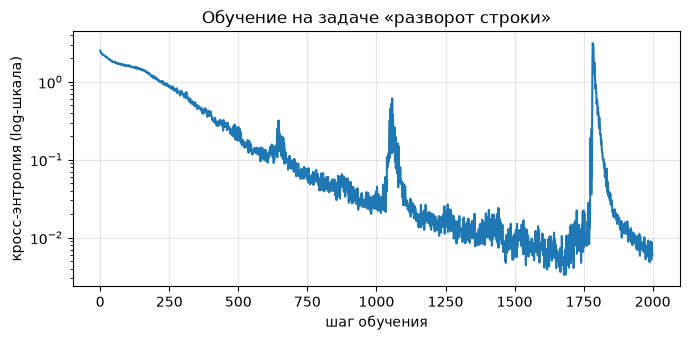

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3.5))
plt.semilogy(losses)
plt.xlabel("шаг обучения")
plt.ylabel("кросс-энтропия (log-шкала)")
plt.title("Обучение на задаче «разворот строки»")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

![](transformer_pictures/training_loss.png)

Редкие всплески на кривой — не ошибка: у Adam на маленьких моделях изредка случаются градиентные выбросы, после которых loss за десятки шагов возвращается на траекторию. В больших моделях с такими всплесками борются разогревом learning rate и градиентным клиппингом; нашей игрушечной задаче достаточно того, что обучение само восстанавливается.

В оригинальной статье к кросс-энтропии добавляют **label smoothing** (целевое one-hot распределение слегка размазывают по словарю, $\varepsilon = 0.1$) — это регуляризация, полезная на настоящих данных; для нашей задачи она не нужна.

## Инференс: генерация по токену

Обученная модель предсказывает следующий токен — а как получить целую последовательность? Так же, как генерировала языковая модель в части 0: по одному токену за раз. Начинаем с `<bos>`, предсказываем первый токен, дописываем его к входу декодера, предсказываем второй — и так далее. Простейшая стратегия — **greedy decoding**: на каждом шаге берём самый вероятный токен.

In [10]:
@torch.no_grad()
def greedy_decode(model, src, out_len):
    enc_out = model.encode(src)                       # источник кодируем один раз
    ys = torch.zeros(src.shape[0], 1, dtype=torch.long)   # <bos>
    for _ in range(out_len):
        logits = model.decode(ys, enc_out)
        next_tok = logits[:, -1].argmax(-1, keepdim=True)
        ys = torch.cat([ys, next_tok], dim=1)
    return ys[:, 1:]

src, _, tgt = make_batch(1000)
pred = greedy_decode(model, src, seq_len)
exact = (pred == tgt).all(dim=1).float().mean()
print(f"точность (полное совпадение): {exact:.1%}")

точность (полное совпадение): 99.5%


```text
точность (полное совпадение): 99.5%
```

Посмотрим на предсказания глазами. Числовые токены — условность; отобразим символы 1–10 латинскими буквами a–j, чтобы разворот было видно буквально:

In [11]:
def to_str(tokens):
    return "".join(chr(ord("a") + t - 1) for t in tokens.tolist())

for i in range(5):
    ok = "✓" if (pred[i] == tgt[i]).all() else "✗"
    print(f"{to_str(src[i])} → {to_str(pred[i])}  {ok}")

wrong = (pred != tgt).any(dim=1).nonzero().flatten()
if len(wrong) > 0:
    i = wrong[0]
    print(f"\nпример ошибки: {to_str(src[i])} → {to_str(pred[i])}")
    print(f"правильно:     {' ' * (seq_len + 3)}{to_str(tgt[i])}")

gjcfhghhfg → gfhhghfcjg  ✓
hgfcacbgah → hagbcacfgh  ✓
gehbahfgja → ajgfhabheg  ✓
ieidhjgfag → gafgjhdiei  ✓
jjbbifcije → ejicfibbjj  ✓

пример ошибки: bhchhicehh → hhecihhcbh
правильно:                  hhecihhchb


```text
gjcfhghhfg → gfhhghfcjg  ✓
hgfcacbgah → hagbcacfgh  ✓
gehbahfgja → ajgfhabheg  ✓
ieidhjgfag → gafgjhdiei  ✓
jjbbifcije → ejicfibbjj  ✓

пример ошибки: bhchhicehh → hhecihhcbh
правильно:                  hhecihhchb
```

Показателен и сам характер редких ошибок: они случаются на строках с многократными повторами одного символа (в примере выше — пять «h»). Это не совпадение: одинаковые токены имеют одинаковые эмбеддинги, и различить их attention может только по позиционной составляющей — тому самому positional encoding из части 2. Копирование в обратном порядке — это, по сути, чистая работа с позициями, и именно она отказывает первой.

Greedy — не единственная стратегия. Жадный выбор необратим: одна ошибка в начале портит весь хвост, даже если модель «знала» вариант получше. **Beam search** смягчает это: на каждом шаге хранится не один, а $k$ лучших префиксов (по суммарному log-правдоподобию), и финальный ответ выбирается из $k$ полных гипотез. В переводе типичные $k = 4\text{–}8$ дают заметный прирост качества; для нашей игрушечной задачи, где модель уверена в каждом токене, достаточно greedy.

## Память при обучении: скрытая цена квадратичности

FLOPs мы считали всю серию, но у обучения есть вторая валюта — **память**. Для backward нужно хранить активации всех промежуточных слоёв: градиенты вычисляются по цепному правилу от выхода ко входу, и каждому слою для этого нужны его входы, посчитанные на forward.

Самая прожорливая активация — таблица весов внимания: $n \times n$ на **каждую голову каждого слоя**. Прикинем для скромного по нынешним меркам конфига:

In [12]:
n, h_, N_ = 4096, 8, 12       # длина контекста, голов, слоёв
attn_bytes = N_ * h_ * n * n * 4        # float32
print(f"матрицы внимания: {attn_bytes / 2**30:.1f} GiB на один пример")

матрицы внимания: 6.0 GiB на один пример


Шесть гигабайт — только на таблицы внимания, только для одного примера в батче, и мы ещё не считали активации FFN и градиенты с состоянием оптимизатора. FLOPs при этом вполне подъёмные — упираемся мы именно в память: она растёт как $O(N \cdot h \cdot n^2)$, и удвоение длины контекста учетверяет счёт. Поэтому длинный контекст исторически был проблемой памяти, а не арифметики.

> 💡 Современные реализации attention (например, FlashAttention) не материализуют таблицу $n \times n$ целиком: скоры считаются блоками и сразу сворачиваются в выход, а на backward недостающее пересчитывается. Квадратичность FLOPs остаётся, квадратичность памяти — уходит. Это за рамками нашей серии, но знать, что «квадратичная память» — не приговор, полезно.

## KV-cache: не пересчитывать прошлое

Присмотримся к нашему `greedy_decode`. На шаге $t$ мы вызываем `model.decode` для **всего** префикса из $t$ токенов: заново считаем Q, K, V для токенов, которые не изменились, заново строим таблицу внимания $t \times t$. Стоимость шага $t$ — $O(t^2 \cdot d)$, а всей генерации из $T$ токенов — $O(T^3 \cdot d)$. Расточительно: от шага к шагу в префиксе меняется ровно один токен.

Ключевое наблюдение: новому токену для attention нужны его собственный запрос $q_t$ — и ключи со значениями **всех предыдущих** токенов, которые мы уже вычисляли на прошлых шагах. Значит, их можно закэшировать: храним накопленные $K$ и $V$ (по паре на слой), на каждом шаге считаем проекции только для одного нового токена и дописываем их в кэш. Это и есть **KV-cache**. Стоимость шага $t$ падает до $O(t \cdot d)$: один запрос против $t$ ключей. Вся генерация из $T$ токенов дешевеет с $\sum_t O(t^2 d) = O(T^3 \cdot d)$ до $\sum_t O(t \cdot d) = O(T^2 \cdot d)$ — на порядок по $T$; квадратичность остаётся (последний токен всё равно смотрит на всех предшественников), но кубическая расточительность уходит.

Проверим на уровне одного attention-слоя, что инкрементальная генерация с кэшем даёт в точности то же, что полный пересчёт с causal-маской:

In [13]:
mha = MultiHeadAttention(d, h)
x = torch.randn(1, 20, d)

with torch.no_grad():
    full = mha(x, x, x, causal_mask(20))          # полный пересчёт

    k_cache, v_cache, outs = None, None, []
    for t in range(x.shape[1]):
        x_t = x[:, t : t + 1]                     # только новый токен
        q = mha.split_heads(mha.w_q(x_t))
        k_new = mha.split_heads(mha.w_k(x_t))
        v_new = mha.split_heads(mha.w_v(x_t))
        k_cache = k_new if k_cache is None else torch.cat([k_cache, k_new], dim=2)
        v_cache = v_new if v_cache is None else torch.cat([v_cache, v_new], dim=2)
        out, _ = scaled_dot_product_attention(q, k_cache, v_cache)
        outs.append(mha.w_o(out.transpose(1, 2).reshape(1, 1, mha.d)))
    incremental = torch.cat(outs, dim=1)

assert torch.allclose(full, incremental, atol=1e-5)
print("KV-cache: совпадает с полным пересчётом")

KV-cache: совпадает с полным пересчётом


Заметьте: causal-маска в инкрементальном варианте не понадобилась. Кэш **и есть** прошлое — новый токен физически не может посмотреть в будущее, потому что будущих ключей ещё не существует. Маска нужна только при обучении, когда все позиции считаются одновременно.

Платим за ускорение памятью: кэш хранит $2 \cdot N \cdot t \cdot d$ чисел и растёт линейно с длиной генерации — при длинных диалогах с большими моделями именно KV-cache занимает заметную часть памяти GPU. Такой размен — пересчёт на хранение — классика инженерии, и в части 2 мы уже видели его зеркальное отражение: FlashAttention меняет хранение на пересчёт.

## 📦 Сложность трансформера: сводка всей серии

Обещанный итог — все ответы в одном месте.

**Формулы по блокам** (выведены в части 2):

| Блок | Сложность |
|---|---|
| Эмбеддинги | $O(n \cdot d)$ |
| Positional encoding | $O(n \cdot d)$ |
| Multi-head attention | $O(n^2 \cdot d + n \cdot d^2)$ |
| FFN | $O(n \cdot d \cdot d_{ff})$, при $d_{ff}=4d$ — $O(n \cdot d^2)$ |
| Add & Norm | $O(n \cdot d)$ |
| Выходная проекция | $O(n \cdot d \cdot \lvert V \rvert)$ |

**Итого для модели из $N$ слоёв:**

$$
\underbrace{O\big(N \cdot (n^2 d + n d^2)\big)}_{\text{слои}} \;+\; \underbrace{O(n \cdot d \cdot |V|)}_{\text{выход}}.
$$

**Сравнение с RNN** (выведено в части 1):

| | FLOPs на слой | Последовательных операций | Путь между токенами |
|---|---|---|---|
| Self-attention | $O(n^2 \cdot d)$ | $O(1)$ | $O(1)$ |
| RNN | $O(n \cdot d^2)$ | $O(n)$ | $O(n)$ |

Выигрыш трансформера — не в FLOPs (их может быть и больше), а в двух правых колонках: параллелизм и короткие пути для градиента.

**Где боттлнек?** Смотрим на $O(n^2 d + n d^2)$ и сравниваем $n$ с $d$:

- $n \gg d$ (длинные контексты): доминирует $n^2 d$ — attention. Отсюда вся индустрия «дешёвого» attention.
- $n \approx d$: оба слагаемых $O(n^3)$, выделенного боттлнека нет.
- $n \ll d$ (типичный перевод: $n \sim 50$, $d = 512\text{–}1024$): доминирует $n d^2$ — **линейные проекции и FFN**, а вовсе не attention. Это стоит проговорить, потому что противоречит расхожему мифу: на коротких последовательностях квадратичность attention практически незаметна, основные FLOPs уходят в обычные матричные умножения.

**«Сложность» — это три разных вопроса:**

1. **FLOPs обучения:** форвард $O(N(n^2 d + n d^2) + n d |V|)$ на пример, backward ещё примерно вдвое дороже форварда; итого обучение стоит порядка трёх форвардов.
2. **Память обучения:** активации для backward, худшая — таблицы внимания $O(N \cdot h \cdot n^2)$. Квадратичная память упирается в железо раньше, чем квадратичные FLOPs.
3. **Стоимость инференса:** наивная генерация — $O(t^2 d)$ на токен; с KV-cache — $O(t \cdot d)$ на токен ценой кэша размером $O(N \cdot t \cdot d)$, растущего с длиной диалога.

## Финал серии

Мы прошли путь целиком: от seq2seq и языковых моделей (часть 0) через мотивацию «зачем выкидывать RNN» (часть 1) и сборку каждого блока руками с проверкой на numpy (часть 2) — до работающей модели, которая обучилась, генерирует и укладывается в посчитанные нами формулы (часть 3). Трансформер перестал быть чёрным ящиком: это десяток маленьких деталей, каждая из которых умещается в 10–20 строк кода и одну формулу сложности.

Куда двигаться дальше, если хочется глубже: токенизация BPE, decoder-only архитектуры (GPT), эффективный attention (FlashAttention и родня), квантизация и всё, что делает инференс дешёвым. Но это уже другие истории.